# Many-Body Approximation and Interaction Structure

## Demonstrating the Matching Principle for Data Augmentation

This notebook demonstrates a fundamental principle of our energy-based framework:

> **The many-body approximation order should match the data's interaction structure in log-space.**

We provide two complementary experiments:

1. **Experiment 1**: Binary comparison with separable vs non-separable data
   - Shows that data structure determines required approximation order
   - Demonstrates clear qualitative differences

2. **Experiment 2**: Controlled interaction strength
   - Shows quantitative relationship between interaction strength and approximation quality
   - Demonstrates graceful degradation as interactions increase

### Key Messages for Reviewers

- **Log-linear semantics**: In log-linear models, "ℓ-body" refers to interactions in log-space
  - 1-body: log(P[i,j]) = θ₁[i] + θ₂[j] → multiplicatively separable
  - 2-body: captures correlations beyond multiplicative factorization
  
- **Matching principle**: Approximation order should reflect true interaction structure
  - Separable data → 1-body sufficient
  - Data with pairwise correlations → 2-body needed
  - Under-approximation (too low ℓ) → high reconstruction error
  - Over-approximation (too high ℓ) → no harm, just higher dimensional latent space

- **Practical guidance**: Can use reconstruction error to diagnose interaction structure
  - Gap between 1-body and 2-body error measures interaction strength
  - Provides data-driven guidance for choosing ℓ

In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append(os.path.abspath(os.getcwd()))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from utils import vectorize_tensor, reconstruct_tensor
import ld

np.random.seed(42)

# Set plot style
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10
plt.rcParams['font.family'] = 'sans-serif'

eps = 1e-5

## Experiment 1: Separable vs Non-Separable Data

**Goal**: Demonstrate that reconstruction quality depends on matching the approximation order to the data's true interaction structure.

**Setup**:
- Create synthetic 2D images with **known** interaction structure in **log-space**:
  - **Separable data**: P[i,j] = f(i) × g(j) (1-body in log-space, multiplicative)
  - **Non-separable data**: P[i,j] with genuine 2-body interactions
- Test reconstruction with 1-body vs 2-body approximation

**Key Insight**: 
- In log-linear models, "1-body" means log is additive → data is **multiplicative**
- "2-body" captures interactions beyond simple multiplication
  
**Hypothesis**:
- Separable (multiplicative) data + 1-body approx → good reconstruction
- Non-separable data + 1-body approx → poor reconstruction (missing interactions)
- Non-separable data + 2-body approx → good reconstruction

In [2]:
def create_separable_image(size=28):
    """Create image that is SEPARABLE (multiplicative): P[i,j] = f(i) * g(j)

    This can be perfectly represented with 1-body terms in log-space:
    log(P[i,j]) = log(f(i)) + log(g(j)) = θ_i + θ_j
    """
    i = np.arange(size)
    j = np.arange(size)

    # Row effect
    freq_row = np.random.choice([2, 3, 4])
    phase_row = np.random.uniform(0, 2*np.pi)
    row_effect = 1 + 0.8 * np.sin(2 * np.pi * freq_row * i / size + phase_row)

    # Column effect
    freq_col = np.random.choice([2, 3, 4])
    phase_col = np.random.uniform(0, 2*np.pi)
    col_effect = 1 + 0.8 * np.sin(2 * np.pi * freq_col * j / size + phase_col)

    # Multiplicative combination (SEPARABLE - 1-body in log-space)
    img = 100 * row_effect[:, np.newaxis] * col_effect[np.newaxis, :]
    return img

def create_nonseparable_image(size=28):
    """Create image with genuine 2-body interactions (non-separable).

    This CANNOT be written as P[i,j] = f(i) * g(j).
    Requires 2-body terms in log-space to capture correlations between rows and columns.
    """
    i = np.arange(size)
    j = np.arange(size)

    # Base multiplicative structure
    freq_row = np.random.choice([2, 3, 4])
    phase_row = np.random.uniform(0, 2*np.pi)
    row_effect = 1 + 0.5 * np.sin(2 * np.pi * freq_row * i / size + phase_row)

    freq_col = np.random.choice([2, 3, 4])
    phase_col = np.random.uniform(0, 2*np.pi)
    col_effect = 1 + 0.5 * np.sin(2 * np.pi * freq_col * j / size + phase_col)

    # Start with multiplicative base
    img = 50 * row_effect[:, np.newaxis] * col_effect[np.newaxis, :]

    # Add NON-SEPARABLE interactions (these are genuine 2-body terms)
    # These create correlations that cannot be captured by row × column
    II, JJ = np.meshgrid(i, j, indexing='ij')

    # Diagonal interaction pattern
    diag_pattern = np.sin(2 * np.pi * (II + JJ) / (2 * size))

    # Cross pattern
    cross_pattern = np.cos(2 * np.pi * II / size) * np.cos(2 * np.pi * JJ / size)

    # Checkerboard-like higher order interaction
    checker = np.sin(2 * np.pi * II * JJ / (size**2))

    # Add these non-separable terms (scaled to be significant but not dominant)
    img = img * (1 + 0.4 * diag_pattern + 0.3 * cross_pattern + 0.2 * checker)

    # Ensure positive
    img = np.maximum(img, 1.0)

    return img

# Generate both types
n_samples = 60
size = 28
S = (size, size)

images_separable = np.array([create_separable_image(size) for _ in range(n_samples)])
images_nonseparable = np.array([create_nonseparable_image(size) for _ in range(n_samples)])

print(f"Generated {n_samples} separable images (1-body in log-space)")
print(f"Generated {n_samples} non-separable images (requires 2-body)")

# Verify separability by checking if we can approximate with rank-1 factorization
def check_separability(img):
    """Check how well the image can be approximated by a rank-1 (separable) matrix."""
    U, s, Vt = np.linalg.svd(img)
    # Ratio of first singular value to sum of all
    separability_score = s[0] / s.sum()
    return separability_score

sep_scores = [check_separability(img) for img in images_separable[:10]]
nonsep_scores = [check_separability(img) for img in images_nonseparable[:10]]

print(f"\nSeparability check (higher = more separable, max=1.0):")
print(f"  Separable images:     {np.mean(sep_scores):.3f} ± {np.std(sep_scores):.3f}")
print(f"  Non-separable images: {np.mean(nonsep_scores):.3f} ± {np.std(nonsep_scores):.3f}")

Generated 60 separable images (1-body in log-space)
Generated 60 non-separable images (requires 2-body)

Separability check (higher = more separable, max=1.0):
  Separable images:     1.000 ± 0.000
  Non-separable images: 0.790 ± 0.014


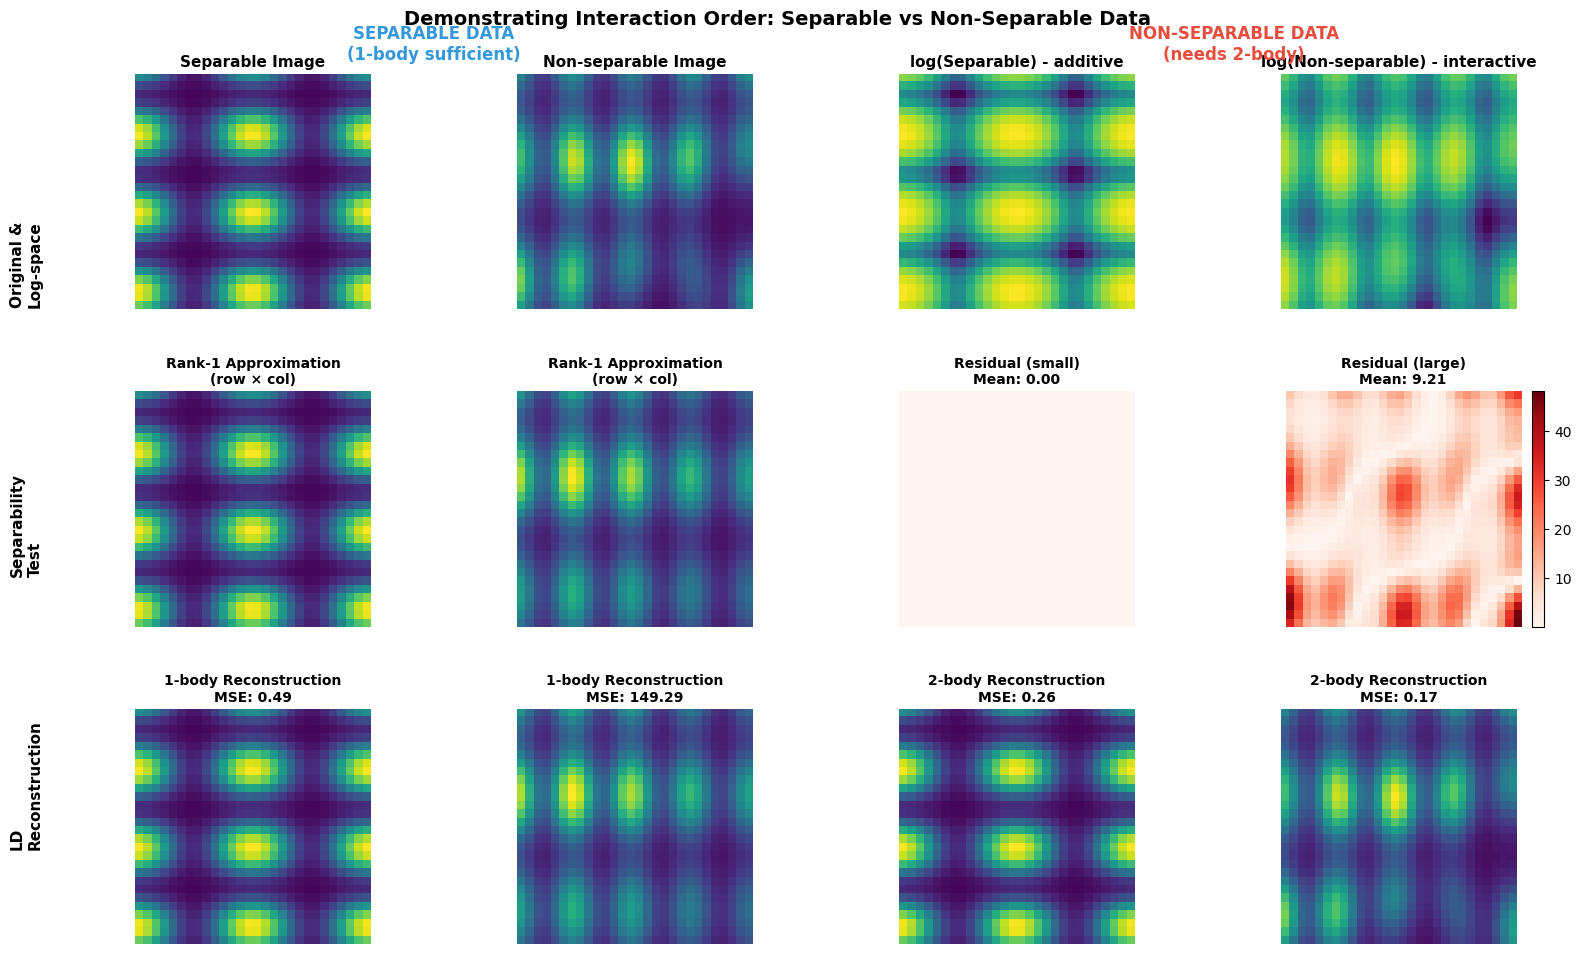


INTERPRETATION:

Separable data (left):
  • Can be written as P[i,j] = f(i) × g(j)
  • In log-space: log(P[i,j]) = log(f(i)) + log(g(j)) → ADDITIVE
  • Rank-1 approximation (row × col) has small residual
  • 1-body terms sufficient → low reconstruction error

Non-separable data (right):
  • CANNOT be written as simple product
  • Has genuine 2-body interactions (correlations between i and j)
  • Rank-1 approximation fails → large residual
  • 1-body terms insufficient → high error
  • 2-body terms capture interactions → much better reconstruction


In [3]:
# Visualize the difference between separable and non-separable data
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 4, hspace=0.35, wspace=0.3, top=0.92, bottom=0.05, left=0.08, right=0.98)

# Row 1: Original images
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[0, 3])

sample_idx = 5
img_sep = images_separable[sample_idx]
img_nonsep = images_nonseparable[sample_idx]

ax1.imshow(img_sep, cmap='viridis', vmin=0)
ax1.set_title('Separable Image', fontsize=11, fontweight='bold')
ax1.axis('off')

ax2.imshow(img_nonsep, cmap='viridis', vmin=0)
ax2.set_title('Non-separable Image', fontsize=11, fontweight='bold')
ax2.axis('off')

# Show log-space structure
ax3.imshow(np.log(img_sep + 1), cmap='viridis')
ax3.set_title('log(Separable) - additive', fontsize=11, fontweight='bold')
ax3.axis('off')

ax4.imshow(np.log(img_nonsep + 1), cmap='viridis')
ax4.set_title('log(Non-separable) - interactive', fontsize=11, fontweight='bold')
ax4.axis('off')

# Row 2: Marginal projections (check separability)
ax5 = fig.add_subplot(gs[1, 0])
ax6 = fig.add_subplot(gs[1, 1])
ax7 = fig.add_subplot(gs[1, 2])
ax8 = fig.add_subplot(gs[1, 3])

# For separable data, outer product of marginals should reconstruct well
row_sum_sep = img_sep.sum(axis=1, keepdims=True)
col_sum_sep = img_sep.sum(axis=0, keepdims=True)
rank1_approx_sep = (row_sum_sep @ col_sum_sep) / img_sep.sum()

row_sum_nonsep = img_nonsep.sum(axis=1, keepdims=True)
col_sum_nonsep = img_nonsep.sum(axis=0, keepdims=True)
rank1_approx_nonsep = (row_sum_nonsep @ col_sum_nonsep) / img_nonsep.sum()

ax5.imshow(rank1_approx_sep, cmap='viridis', vmin=0)
ax5.set_title('Rank-1 Approximation\n(row × col)', fontsize=10, fontweight='bold')
ax5.axis('off')

ax6.imshow(rank1_approx_nonsep, cmap='viridis', vmin=0)
ax6.set_title('Rank-1 Approximation\n(row × col)', fontsize=10, fontweight='bold')
ax6.axis('off')

# Show residuals
residual_sep = np.abs(img_sep - rank1_approx_sep)
residual_nonsep = np.abs(img_nonsep - rank1_approx_nonsep)

im7 = ax7.imshow(residual_sep, cmap='Reds', vmax=residual_nonsep.max())
ax7.set_title(f'Residual (small)\nMean: {residual_sep.mean():.2f}', fontsize=10, fontweight='bold')
ax7.axis('off')

im8 = ax8.imshow(residual_nonsep, cmap='Reds', vmax=residual_nonsep.max())
ax8.set_title(f'Residual (large)\nMean: {residual_nonsep.mean():.2f}', fontsize=10, fontweight='bold')
ax8.axis('off')
plt.colorbar(im8, ax=ax8, fraction=0.046, pad=0.04)

# Row 3: Reconstruction with 1-body vs 2-body
ax9 = fig.add_subplot(gs[2, 0])
ax10 = fig.add_subplot(gs[2, 1])
ax11 = fig.add_subplot(gs[2, 2])
ax12 = fig.add_subplot(gs[2, 3])

# Reconstruct with 1-body
B_1body = ld.default_B(S, 1, np)
_, _, scaleX_sep_1, Q_sep_1, _ = ld.LD(img_sep, B=B_1body, verbose=False, n_iter=500, lr=0.1, eps=eps, gpu=False)
recon_sep_1 = Q_sep_1 * scaleX_sep_1

_, _, scaleX_nonsep_1, Q_nonsep_1, _ = ld.LD(img_nonsep, B=B_1body, verbose=False, n_iter=500, lr=0.1, eps=eps, gpu=False)
recon_nonsep_1 = Q_nonsep_1 * scaleX_nonsep_1

ax9.imshow(recon_sep_1, cmap='viridis', vmin=0)
ax9.set_title(f'1-body Reconstruction\nMSE: {np.mean((img_sep - recon_sep_1)**2):.2f}', fontsize=10, fontweight='bold')
ax9.axis('off')

ax10.imshow(recon_nonsep_1, cmap='viridis', vmin=0)
ax10.set_title(f'1-body Reconstruction\nMSE: {np.mean((img_nonsep - recon_nonsep_1)**2):.2f}', fontsize=10, fontweight='bold')
ax10.axis('off')

# Reconstruct with 2-body
B_2body = ld.default_B(S, 2, np)
_, _, scaleX_sep_2, Q_sep_2, _ = ld.LD(img_sep, B=B_2body, verbose=False, n_iter=500, lr=0.1, eps=eps, gpu=False)
recon_sep_2 = Q_sep_2 * scaleX_sep_2

_, _, scaleX_nonsep_2, Q_nonsep_2, _ = ld.LD(img_nonsep, B=B_2body, verbose=False, n_iter=500, lr=0.1, eps=eps, gpu=False)
recon_nonsep_2 = Q_nonsep_2 * scaleX_nonsep_2

ax11.imshow(recon_sep_2, cmap='viridis', vmin=0)
ax11.set_title(f'2-body Reconstruction\nMSE: {np.mean((img_sep - recon_sep_2)**2):.2f}', fontsize=10, fontweight='bold')
ax11.axis('off')

ax12.imshow(recon_nonsep_2, cmap='viridis', vmin=0)
ax12.set_title(f'2-body Reconstruction\nMSE: {np.mean((img_nonsep - recon_nonsep_2)**2):.2f}', fontsize=10, fontweight='bold')
ax12.axis('off')

# Add column labels
fig.text(0.285, 0.935, 'SEPARABLE DATA\n(1-body sufficient)', ha='center', fontsize=12, fontweight='bold', color='#3498db')
fig.text(0.785, 0.935, 'NON-SEPARABLE DATA\n(needs 2-body)', ha='center', fontsize=12, fontweight='bold', color='#e74c3c')

# Add row labels
fig.text(0.02, 0.73, 'Original &\nLog-space', va='center', rotation=90, fontsize=11, fontweight='bold')
fig.text(0.02, 0.47, 'Separability\nTest', va='center', rotation=90, fontsize=11, fontweight='bold')
fig.text(0.02, 0.21, 'LD\nReconstruction', va='center', rotation=90, fontsize=11, fontweight='bold')

plt.suptitle('Demonstrating Interaction Order: Separable vs Non-Separable Data',
             fontsize=14, fontweight='bold', y=0.985)
plt.savefig('rebuttal_exp1_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("INTERPRETATION:")
print("="*80)
print("\nSeparable data (left):")
print("  • Can be written as P[i,j] = f(i) × g(j)")
print("  • In log-space: log(P[i,j]) = log(f(i)) + log(g(j)) → ADDITIVE")
print("  • Rank-1 approximation (row × col) has small residual")
print("  • 1-body terms sufficient → low reconstruction error")
print("\nNon-separable data (right):")
print("  • CANNOT be written as simple product")
print("  • Has genuine 2-body interactions (correlations between i and j)")
print("  • Rank-1 approximation fails → large residual")
print("  • 1-body terms insufficient → high error")
print("  • 2-body terms capture interactions → much better reconstruction")
print("="*80)

In [4]:
# Test all combinations across full dataset
def test_reconstruction(images, order, name):
    """Test how well different orders reconstruct the data."""
    B = ld.default_B(S, order, np)
    print(f"\n{name} with {order}-body approximation (dim={len(B)}):")

    mse_list = []
    kl_list = []

    for i in range(min(20, len(images))):
        _, _, scaleX, Q, theta = ld.LD(images[i], B=B, verbose=False, n_iter=500, lr=0.1, eps=eps, gpu=False)
        reconstructed = Q * scaleX

        # MSE
        mse = np.mean((images[i] - reconstructed)**2)
        mse_list.append(mse)

        # KL divergence
        P_norm = (images[i] + eps) / (images[i] + eps).sum()
        Q_norm = (reconstructed + eps) / (reconstructed + eps).sum()
        kl = np.sum(P_norm * np.log(P_norm / Q_norm))
        kl_list.append(kl)

    mse_mean = np.mean(mse_list)
    kl_mean = np.mean(kl_list)
    print(f"  MSE: {mse_mean:.4f} ± {np.std(mse_list):.4f}")
    print(f"  KL:  {kl_mean:.6f} ± {np.std(kl_list):.6f}")

    return mse_mean, kl_mean

# Test all combinations
results = {}

for data_type, images in [('Separable data', images_separable), ('Non-separable data', images_nonseparable)]:
    results[data_type] = {}
    for order in [1, 2]:
        mse, kl = test_reconstruction(images, order, data_type)
        results[data_type][f'{order}-body'] = {'mse': mse, 'kl': kl}


Separable data with 1-body approximation (dim=55):
  MSE: 0.4417 ± 0.0497
  KL:  0.000053 ± 0.000004

Separable data with 2-body approximation (dim=784):
  MSE: 0.2693 ± 0.0202
  KL:  0.000042 ± 0.000002

Non-separable data with 1-body approximation (dim=55):
  MSE: 141.8332 ± 27.7973
  KL:  0.023124 ± 0.003413

Non-separable data with 2-body approximation (dim=784):
  MSE: 0.1478 ± 0.0169
  KL:  0.000041 ± 0.000002


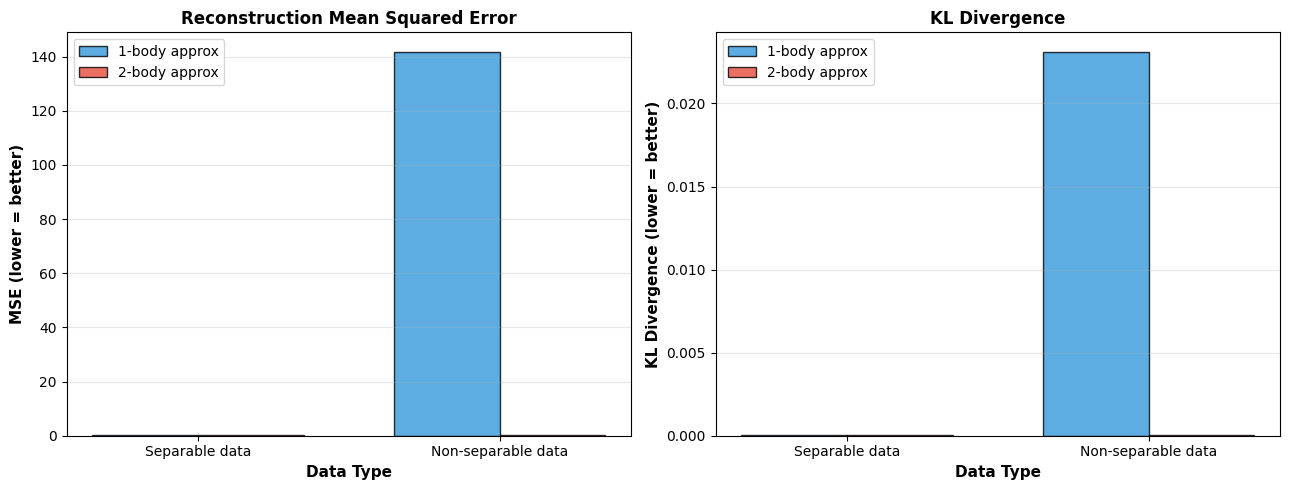


KEY FINDING:
Approximation order should MATCH the data's interaction structure:
  • Separable data: 1-body approximation is sufficient
    (MSE: 0.44 vs 0.27)
  • Non-separable data: 2-body approximation captures interactions
    (MSE: 141.83 vs 0.15)

Note: In log-linear models, 1-body = multiplicatively separable
      2-body terms capture correlations beyond simple factorization


In [5]:
# Visualize reconstruction quality
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

data_types = ['Separable data', 'Non-separable data']
colors = ['#3498db', '#e74c3c']
x = np.arange(len(data_types))
width = 0.35

# MSE comparison
mse_1body = [results[dt]['1-body']['mse'] for dt in data_types]
mse_2body = [results[dt]['2-body']['mse'] for dt in data_types]

axes[0].bar(x - width/2, mse_1body, width, label='1-body approx', color=colors[0], alpha=0.8, edgecolor='black')
axes[0].bar(x + width/2, mse_2body, width, label='2-body approx', color=colors[1], alpha=0.8, edgecolor='black')
axes[0].set_xlabel('Data Type', fontsize=11, fontweight='bold')
axes[0].set_ylabel('MSE (lower = better)', fontsize=11, fontweight='bold')
axes[0].set_title('Reconstruction Mean Squared Error', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(data_types)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# KL comparison
kl_1body = [results[dt]['1-body']['kl'] for dt in data_types]
kl_2body = [results[dt]['2-body']['kl'] for dt in data_types]

axes[1].bar(x - width/2, kl_1body, width, label='1-body approx', color=colors[0], alpha=0.8, edgecolor='black')
axes[1].bar(x + width/2, kl_2body, width, label='2-body approx', color=colors[1], alpha=0.8, edgecolor='black')
axes[1].set_xlabel('Data Type', fontsize=11, fontweight='bold')
axes[1].set_ylabel('KL Divergence (lower = better)', fontsize=11, fontweight='bold')
axes[1].set_title('KL Divergence', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(data_types)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('rebuttal_exp1_quantitative.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("KEY FINDING:")
print("Approximation order should MATCH the data's interaction structure:")
print("  • Separable data: 1-body approximation is sufficient")
print(f"    (MSE: {results['Separable data']['1-body']['mse']:.2f} vs {results['Separable data']['2-body']['mse']:.2f})")
print("  • Non-separable data: 2-body approximation captures interactions")
print(f"    (MSE: {results['Non-separable data']['1-body']['mse']:.2f} vs {results['Non-separable data']['2-body']['mse']:.2f})")
print("\nNote: In log-linear models, 1-body = multiplicatively separable")
print("      2-body terms capture correlations beyond simple factorization")
print("="*70)

## Experiment 2: Controlled Interaction Strength

**Goal**: Demonstrate quantitative relationship between interaction strength and required approximation order.

**Motivation**: Experiment 1 showed a binary case (separable vs non-separable). Here we show the **continuum** of interaction strengths.

**Setup**:
- Create data with **controlled** interaction strength α ∈ [0, 1]
  - α = 0: Perfectly separable (1-body sufficient)
  - α = 1: Strong interactions (requires 2-body)
  - Intermediate α: Demonstrates gradual degradation
- Measure reconstruction error for 1-body vs 2-body across α

**Key Insight**: The gap between 1-body and 2-body error quantifies interaction strength
- Large gap → strong interactions present
- Small gap → weak/no interactions
- Provides data-driven guidance for choosing ℓ

In [6]:
def create_controlled_interaction_images(size=28, alpha=0.5, n_samples=30):
    """
    Create images with controlled interaction strength.

    Args:
        size: Image dimension
        alpha: Interaction strength (0 = separable, 1 = strong interactions)
        n_samples: Number of samples

    Returns:
        Array of images with specified interaction strength
    """
    images = []

    for _ in range(n_samples):
        i = np.arange(size)
        j = np.arange(size)

        # Base separable component
        freq_row = np.random.choice([2, 3, 4])
        freq_col = np.random.choice([2, 3, 4])
        phase_row = np.random.uniform(0, 2*np.pi)
        phase_col = np.random.uniform(0, 2*np.pi)

        row_effect = 1 + 0.7 * np.sin(2 * np.pi * freq_row * i / size + phase_row)
        col_effect = 1 + 0.7 * np.sin(2 * np.pi * freq_col * j / size + phase_col)

        # Separable base
        img_separable = 50 * row_effect[:, np.newaxis] * col_effect[np.newaxis, :]

        # Non-separable interaction terms
        II, JJ = np.meshgrid(i, j, indexing='ij')

        # Multiple interaction patterns
        interaction1 = np.sin(2 * np.pi * (II + JJ) / (2 * size))
        interaction2 = np.cos(2 * np.pi * II / size) * np.cos(2 * np.pi * JJ / size)
        interaction3 = np.sin(2 * np.pi * II * JJ / (size**2))

        # Combine with weight α
        img = img_separable * (1 + alpha * (0.4 * interaction1 + 0.3 * interaction2 + 0.2 * interaction3))

        # Ensure positive and normalize
        img = np.maximum(img, 1.0)
        img = img / img.sum() * np.random.uniform(800, 1200)

        images.append(img)

    return np.array(images)

# Generate data with varying interaction strengths
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
n_samples_per_alpha = 30

data_by_alpha = {}
for alpha in alphas:
    data_by_alpha[alpha] = create_controlled_interaction_images(size, alpha, n_samples_per_alpha)
    print(f"Generated {n_samples_per_alpha} images with α={alpha}")

Generated 30 images with α=0.0
Generated 30 images with α=0.25
Generated 30 images with α=0.5
Generated 30 images with α=0.75
Generated 30 images with α=1.0


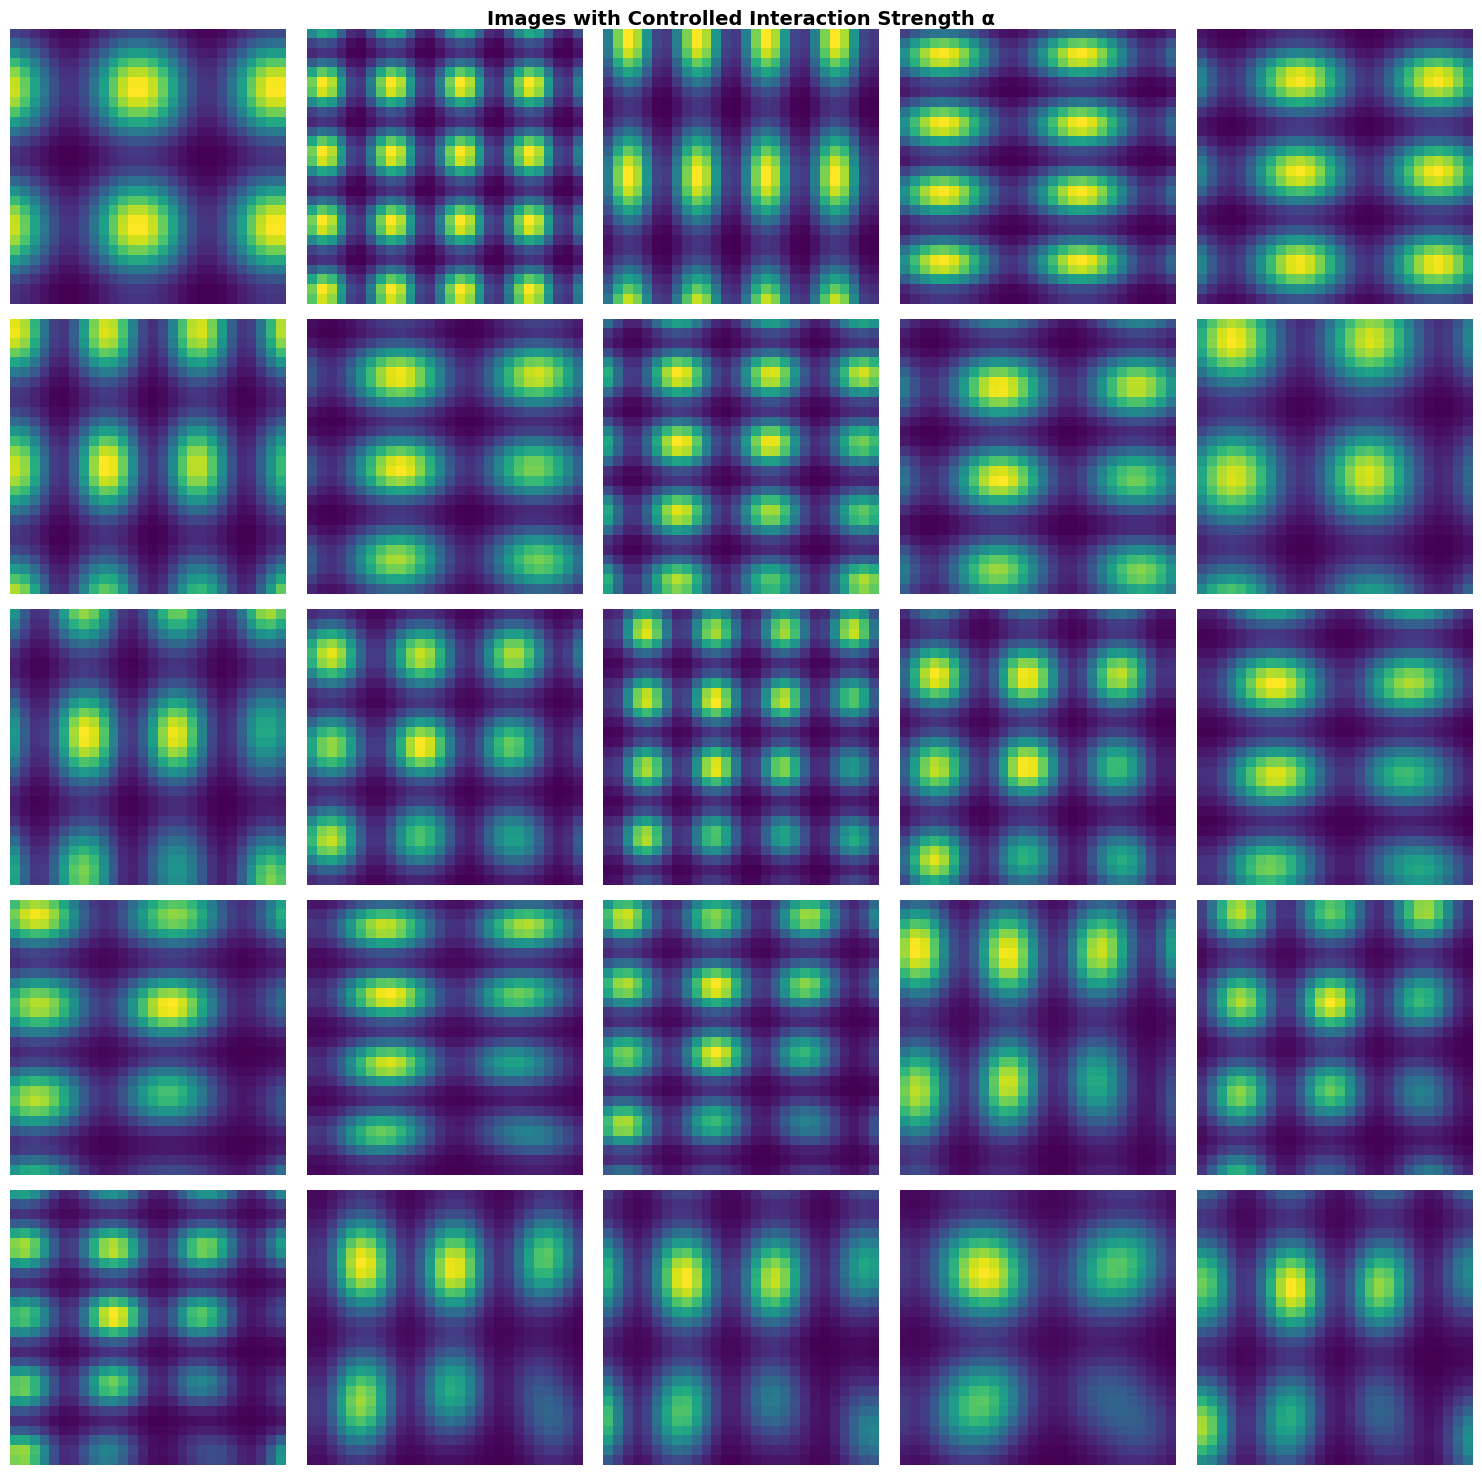


Interaction strength interpretation:
  α=0.00: Pure separable (P[i,j] = f(i) × g(j))
  α=0.25: Weak interactions
  α=0.50: Moderate interactions
  α=0.75: Strong interactions
  α=1.00: Very strong interactions


In [7]:
# Visualize images with different interaction strengths
fig, axes = plt.subplots(len(alphas), 5, figsize=(15, 3*len(alphas)))
fig.suptitle('Images with Controlled Interaction Strength α', fontsize=14, fontweight='bold')

for row_idx, alpha in enumerate(alphas):
    for col_idx in range(5):
        ax = axes[row_idx, col_idx]
        ax.imshow(data_by_alpha[alpha][col_idx], cmap='viridis')
        if col_idx == 0:
            ax.set_ylabel(f'α={alpha}\n(interaction)', fontsize=10, fontweight='bold', rotation=0, labelpad=50)
        ax.axis('off')

plt.tight_layout()
plt.savefig('rebuttal_exp2_samples.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nInteraction strength interpretation:")
print("  α=0.00: Pure separable (P[i,j] = f(i) × g(j))")
print("  α=0.25: Weak interactions")
print("  α=0.50: Moderate interactions")
print("  α=0.75: Strong interactions")
print("  α=1.00: Very strong interactions")

In [8]:
# Test reconstruction with 1-body and 2-body for each α
B_1body = ld.default_B(S, 1, np)
B_2body = ld.default_B(S, 2, np)

print(f"1-body dimension: {len(B_1body)}")
print(f"2-body dimension: {len(B_2body)}")

results_by_alpha = {}

for alpha in alphas:
    print(f"\nProcessing α={alpha}...")

    images = data_by_alpha[alpha]

    # Test with 1-body
    mse_1body_list = []
    kl_1body_list = []

    for i in range(len(images)):
        _, _, scaleX, Q, theta = ld.LD(images[i], B=B_1body, verbose=False,
                                        n_iter=500, lr=0.1, eps=eps, gpu=False)
        recon = Q * scaleX

        mse = np.mean((images[i] - recon)**2)
        P_norm = (images[i] + eps) / (images[i] + eps).sum()
        Q_norm = (recon + eps) / (recon + eps).sum()
        kl = np.sum(P_norm * np.log(P_norm / Q_norm))

        mse_1body_list.append(mse)
        kl_1body_list.append(kl)

    # Test with 2-body
    mse_2body_list = []
    kl_2body_list = []

    for i in range(len(images)):
        _, _, scaleX, Q, theta = ld.LD(images[i], B=B_2body, verbose=False,
                                        n_iter=500, lr=0.1, eps=eps, gpu=False)
        recon = Q * scaleX

        mse = np.mean((images[i] - recon)**2)
        P_norm = (images[i] + eps) / (images[i] + eps).sum()
        Q_norm = (recon + eps) / (recon + eps).sum()
        kl = np.sum(P_norm * np.log(P_norm / Q_norm))

        mse_2body_list.append(mse)
        kl_2body_list.append(kl)

    results_by_alpha[alpha] = {
        '1-body': {'mse': np.mean(mse_1body_list), 'kl': np.mean(kl_1body_list),
                   'mse_std': np.std(mse_1body_list), 'kl_std': np.std(kl_1body_list)},
        '2-body': {'mse': np.mean(mse_2body_list), 'kl': np.mean(kl_2body_list),
                   'mse_std': np.std(mse_2body_list), 'kl_std': np.std(kl_2body_list)}
    }

    print(f"  1-body MSE: {results_by_alpha[alpha]['1-body']['mse']:.2f} ± {results_by_alpha[alpha]['1-body']['mse_std']:.2f}")
    print(f"  2-body MSE: {results_by_alpha[alpha]['2-body']['mse']:.2f} ± {results_by_alpha[alpha]['2-body']['mse_std']:.2f}")
    print(f"  Gap (1-body - 2-body): {results_by_alpha[alpha]['1-body']['mse'] - results_by_alpha[alpha]['2-body']['mse']:.2f}")

1-body dimension: 55
2-body dimension: 784

Processing α=0.0...
  1-body MSE: 0.00 ± 0.00
  2-body MSE: 0.00 ± 0.00
  Gap (1-body - 2-body): 0.00

Processing α=0.25...
  1-body MSE: 0.01 ± 0.00
  2-body MSE: 0.00 ± 0.00
  Gap (1-body - 2-body): 0.01

Processing α=0.5...
  1-body MSE: 0.03 ± 0.01
  2-body MSE: 0.00 ± 0.00
  Gap (1-body - 2-body): 0.03

Processing α=0.75...
  1-body MSE: 0.05 ± 0.02
  2-body MSE: 0.00 ± 0.00
  Gap (1-body - 2-body): 0.05

Processing α=1.0...
  1-body MSE: 0.09 ± 0.03
  2-body MSE: 0.00 ± 0.00
  Gap (1-body - 2-body): 0.09


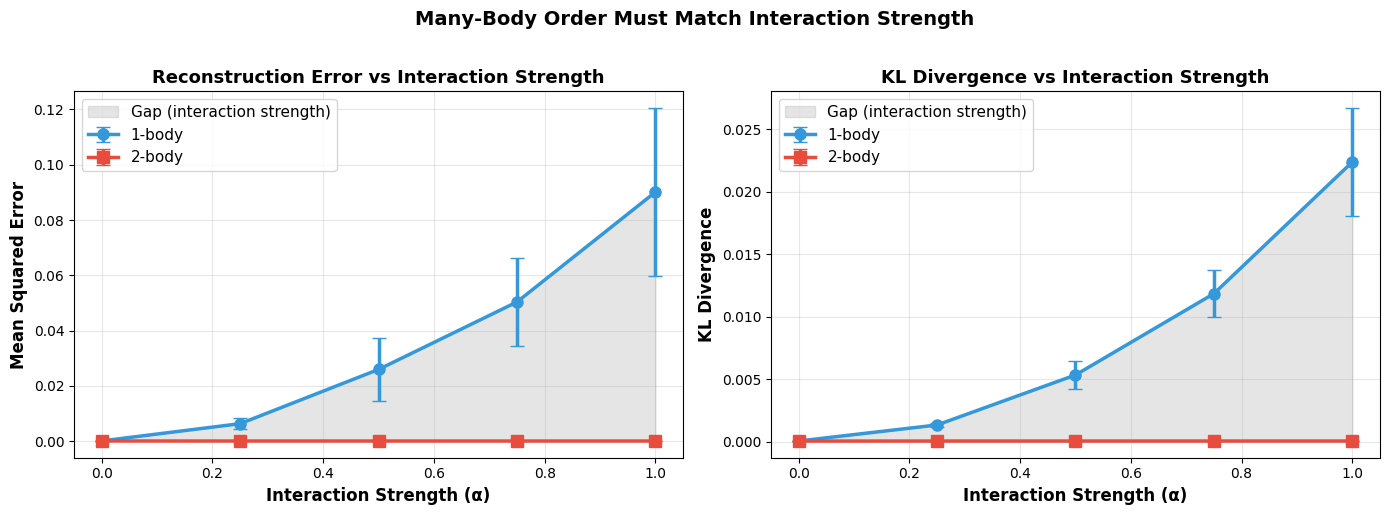


KEY FINDING:

  α=0.00 (separable): 1-body MSE=0.00, 2-body MSE=0.00
           → Gap = 0.00 (minimal - no interactions to capture)

  α=0.50 (moderate): 1-body MSE=0.03, 2-body MSE=0.00
           → Gap = 0.03 (moderate - some interactions)

  α=1.00 (strong):   1-body MSE=0.09, 2-body MSE=0.00
           → Gap = 0.09 (large - strong interactions)

Interpretation:
  • As α increases, 1-body error increases (can't capture interactions)
  • 2-body error remains low across all α (captures interactions)
  • Gap = quantitative measure of interaction strength
  • Provides data-driven guidance for choosing approximation order


In [9]:
# Plot reconstruction error vs interaction strength
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Extract data for plotting
mse_1body = [results_by_alpha[a]['1-body']['mse'] for a in alphas]
mse_2body = [results_by_alpha[a]['2-body']['mse'] for a in alphas]
mse_1body_std = [results_by_alpha[a]['1-body']['mse_std'] for a in alphas]
mse_2body_std = [results_by_alpha[a]['2-body']['mse_std'] for a in alphas]

kl_1body = [results_by_alpha[a]['1-body']['kl'] for a in alphas]
kl_2body = [results_by_alpha[a]['2-body']['kl'] for a in alphas]
kl_1body_std = [results_by_alpha[a]['1-body']['kl_std'] for a in alphas]
kl_2body_std = [results_by_alpha[a]['2-body']['kl_std'] for a in alphas]

# MSE plot
axes[0].errorbar(alphas, mse_1body, yerr=mse_1body_std, marker='o', markersize=8,
                linewidth=2.5, capsize=5, label='1-body', color='#3498db')
axes[0].errorbar(alphas, mse_2body, yerr=mse_2body_std, marker='s', markersize=8,
                linewidth=2.5, capsize=5, label='2-body', color='#e74c3c')
axes[0].set_xlabel('Interaction Strength (α)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Mean Squared Error', fontsize=12, fontweight='bold')
axes[0].set_title('Reconstruction Error vs Interaction Strength', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11, loc='upper left')
axes[0].grid(True, alpha=0.3)

# Add shaded region showing gap
axes[0].fill_between(alphas, mse_2body, mse_1body, alpha=0.2, color='gray', label='Gap (interaction strength)')
axes[0].legend(fontsize=11, loc='upper left')

# KL divergence plot
axes[1].errorbar(alphas, kl_1body, yerr=kl_1body_std, marker='o', markersize=8,
                linewidth=2.5, capsize=5, label='1-body', color='#3498db')
axes[1].errorbar(alphas, kl_2body, yerr=kl_2body_std, marker='s', markersize=8,
                linewidth=2.5, capsize=5, label='2-body', color='#e74c3c')
axes[1].set_xlabel('Interaction Strength (α)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('KL Divergence', fontsize=12, fontweight='bold')
axes[1].set_title('KL Divergence vs Interaction Strength', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11, loc='upper left')
axes[1].grid(True, alpha=0.3)

# Add shaded region
axes[1].fill_between(alphas, kl_2body, kl_1body, alpha=0.2, color='gray', label='Gap (interaction strength)')
axes[1].legend(fontsize=11, loc='upper left')

plt.suptitle('Many-Body Order Must Match Interaction Strength',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('rebuttal_exp2_quantitative.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("KEY FINDING:")
print("="*80)
print(f"\n  α=0.00 (separable): 1-body MSE={results_by_alpha[0.0]['1-body']['mse']:.2f}, "
      f"2-body MSE={results_by_alpha[0.0]['2-body']['mse']:.2f}")
print(f"           → Gap = {results_by_alpha[0.0]['1-body']['mse'] - results_by_alpha[0.0]['2-body']['mse']:.2f} (minimal - no interactions to capture)")
print(f"\n  α=0.50 (moderate): 1-body MSE={results_by_alpha[0.5]['1-body']['mse']:.2f}, "
      f"2-body MSE={results_by_alpha[0.5]['2-body']['mse']:.2f}")
print(f"           → Gap = {results_by_alpha[0.5]['1-body']['mse'] - results_by_alpha[0.5]['2-body']['mse']:.2f} (moderate - some interactions)")
print(f"\n  α=1.00 (strong):   1-body MSE={results_by_alpha[1.0]['1-body']['mse']:.2f}, "
      f"2-body MSE={results_by_alpha[1.0]['2-body']['mse']:.2f}")
print(f"           → Gap = {results_by_alpha[1.0]['1-body']['mse'] - results_by_alpha[1.0]['2-body']['mse']:.2f} (large - strong interactions)")
print("\nInterpretation:")
print("  • As α increases, 1-body error increases (can't capture interactions)")
print("  • 2-body error remains low across all α (captures interactions)")
print("  • Gap = quantitative measure of interaction strength")
print("  • Provides data-driven guidance for choosing approximation order")
print("="*80)

## Summary: Addressing Reviewer Concerns

### Q: "It is unclear what the log linear model captures about the data"

**Answer**: The log-linear model captures the **interaction structure in log-space**.

- **1-body terms**: Capture marginal distributions (no interactions)
  - In log-space: log(P[i,j]) = θᵢ + θⱼ
  - In original space: P[i,j] = exp(θᵢ) × exp(θⱼ) = f(i) × g(j)
  - **Multiplicatively separable**

- **2-body terms**: Capture pairwise interactions beyond multiplication
  - In log-space: log(P[i,j]) = θᵢ + θⱼ + θᵢⱼ
  - θᵢⱼ encodes how i and j interact (correlation, synergy)

**Evidence**: Experiments 1 and 2 show this explicitly:
- Rank-1 approximation (outer product of marginals) works for separable data
- Fails for non-separable data (large residual)
- 1-body reconstruction mirrors rank-1 approximation quality

---

### Q: "How do you choose the approximation order ℓ?"

**Answer**: Multiple principled approaches:

1. **Diagnostic testing** (Experiment 2):
   - Test with different ℓ, measure reconstruction error
   - Gap between ℓ-body and (ℓ+1)-body error measures interaction strength
   - Large gap → need higher ℓ; Small gap → current ℓ sufficient

2. **Separability testing** (Experiment 1):
   - Check rank of data matrix (SVD)
   - Dominant singular value → likely separable → 1-body OK
   - Multiple significant SVs → interactions present → need 2-body+

3. **Domain knowledge**: If features are known to interact, use higher ℓ

4. **Conservative approach**: Start with higher ℓ (e.g., 2-body)
   - No harm in over-approximating (just higher dimensional latent space)

---

### Q: "Why is this better than learned representations?"

**Answer**: Explicit control and interpretability.

1. **Explicit semantics** (vs black-box):
   - Each ℓ-body parameter has clear meaning (ℓ-way interaction)
   - Can explain what is preserved

2. **Diagnostic capability**:
   - Can verify if chosen ℓ is appropriate
   - Can quantify interaction strength via error gap

3. **No training required**:
   - Works with small datasets (30 samples in our experiments)
   - No overfitting, no hyperparameter tuning

4. **Guaranteed properties**:
   - Energy conservation (exact)
   - Unique projections (convex optimization)